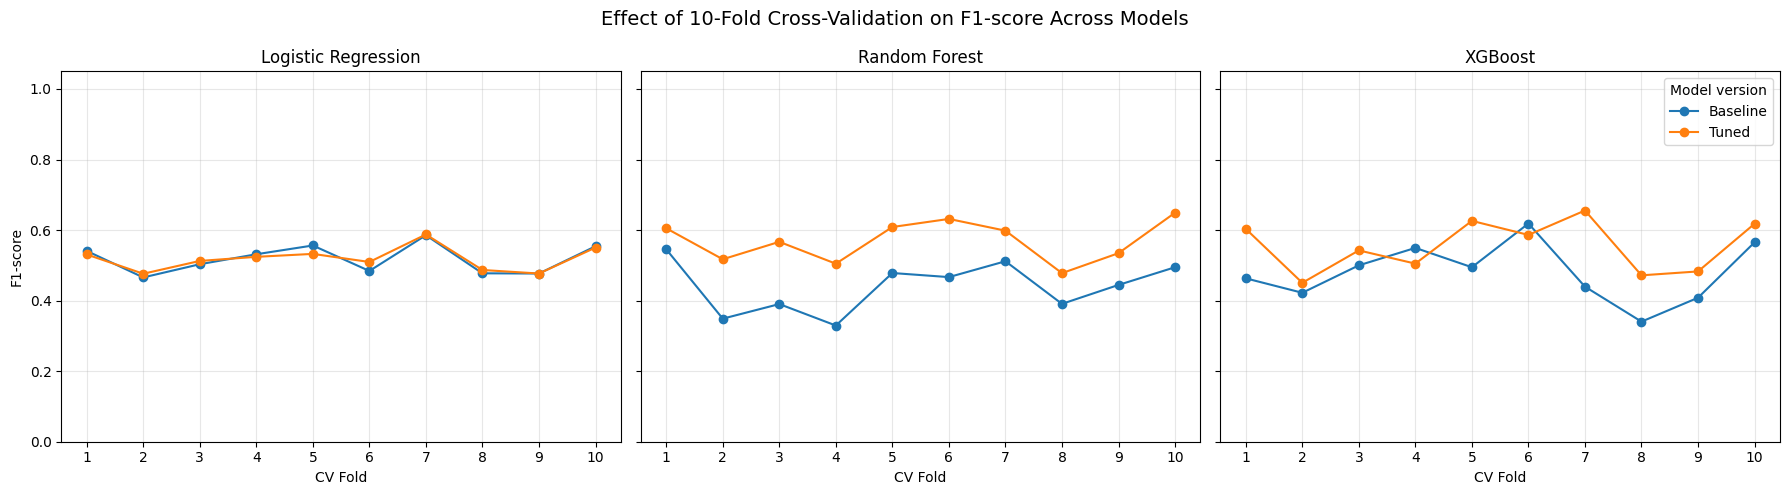

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load fold-by-fold results
lr_cv = pd.read_csv("lr_cv_folds.csv")
rf_cv = pd.read_csv("rf_cv_folds.csv")
xgb_cv = pd.read_csv("xgb_cv_folds.csv")

all_cv_folds = pd.concat([lr_cv, rf_cv, xgb_cv], ignore_index=True)

# Make one image with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models = ["Logistic Regression", "Random Forest", "XGBoost"]

for ax, model in zip(axes, models):
    model_df = all_cv_folds[all_cv_folds["Algorithm"] == model]

    for version in ["Baseline", "Tuned"]:
        version_df = model_df[model_df["Version"] == version]

        ax.plot(
            version_df["Fold"],
            version_df["F1-score"],
            marker="o",
            label=version
        )

    ax.set_title(model)
    ax.set_xlabel("CV Fold")
    ax.set_xticks(range(1, 11))
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("F1-score")
axes[-1].legend(title="Model version")

fig.suptitle("Effect of 10-Fold Cross-Validation on F1-score Across Models", fontsize=14)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [3]:
lr_cv = pd.read_csv("lr_cv_folds.csv")
rf_cv = pd.read_csv("rf_cv_folds.csv")
xgb_cv = pd.read_csv("xgb_cv_folds.csv")

# Combine into one dataframe
cv_folds_df = pd.concat([lr_cv, rf_cv, xgb_cv], ignore_index=True)

# Clean text columns just in case
cv_folds_df["Version"] = cv_folds_df["Version"].astype(str).str.strip()
cv_folds_df["Algorithm"] = cv_folds_df["Algorithm"].astype(str).str.strip()

# Keep only tuned models
tuned_cv = cv_folds_df[cv_folds_df["Version"].str.lower() == "tuned"].copy()

# Make sure folds are ordered
tuned_cv = tuned_cv.sort_values(["Algorithm", "Fold"])

tuned_cv.head()

,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC,Algorithm,Version
10,1,0.832230,0.394495,0.811321,0.530864,0.889009,Logistic Regression,Tuned
11,2,0.829646,0.368421,0.673077,0.476190,0.877452,Logistic Regression,Tuned
12,3,0.827434,0.379630,0.788462,0.512500,0.872163,Logistic Regression,Tuned
13,4,0.847345,0.408602,0.730769,0.524138,0.899279,Logistic Regression,Tuned
14,5,0.840708,0.401961,0.788462,0.532468,0.918125,Logistic Regression,Tuned


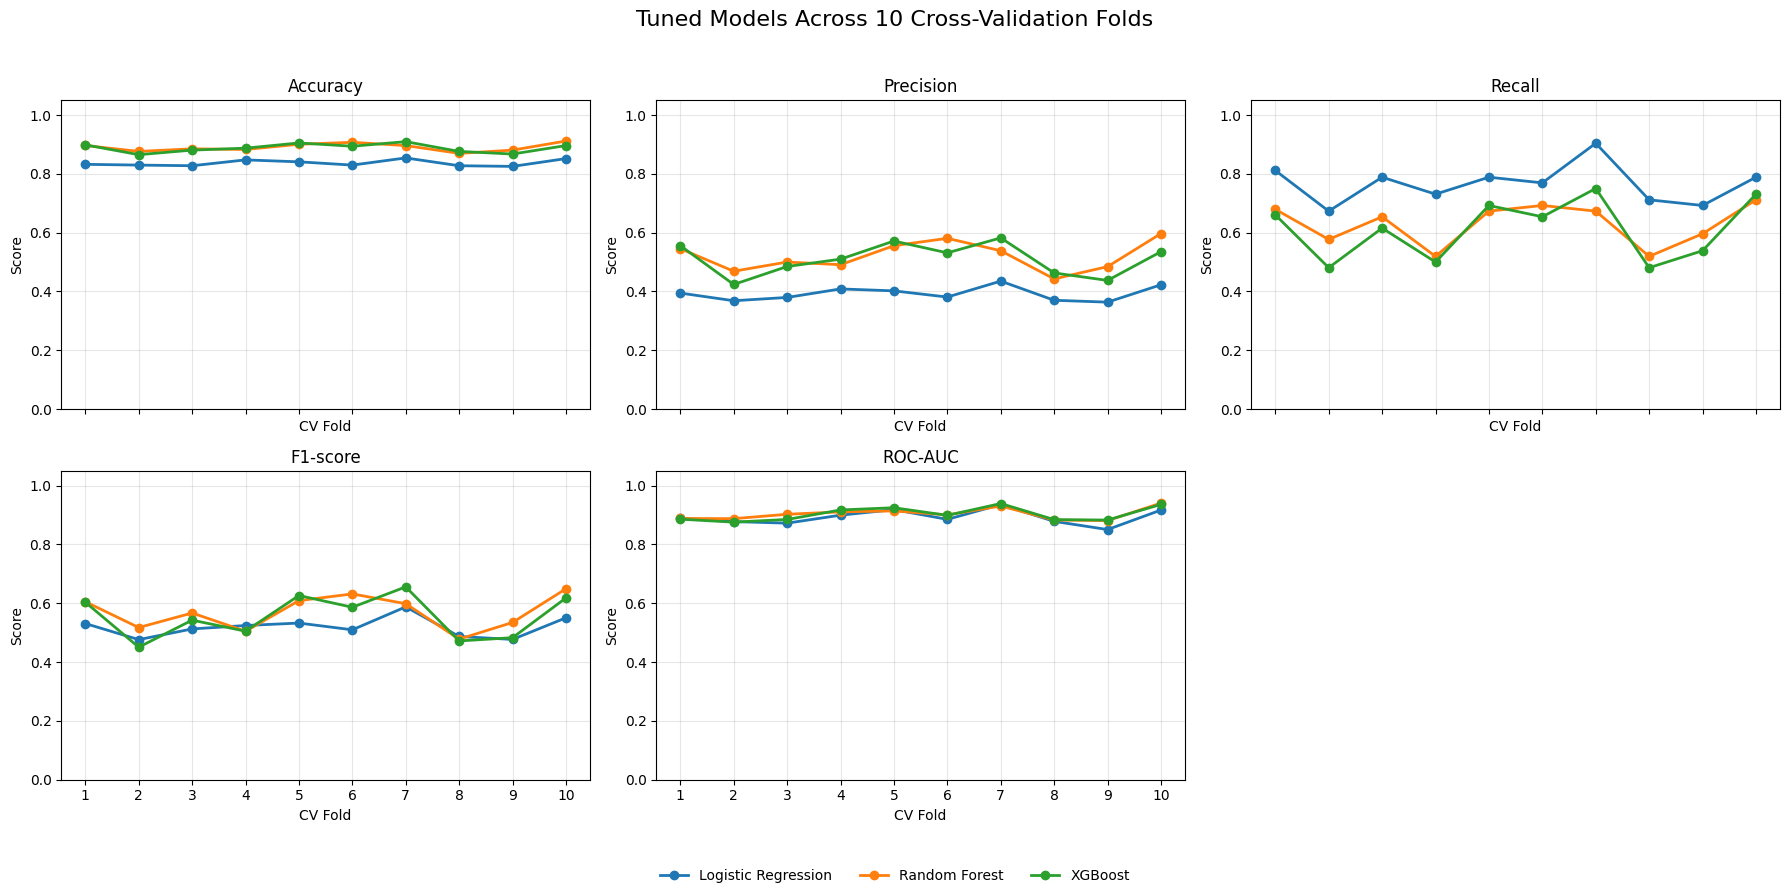

In [4]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
model_order = ["Logistic Regression", "Random Forest", "XGBoost"]

# If your Algorithm column uses shorter labels, this keeps the plot working
label_map = {
    "LR": "Logistic Regression",
    "Logistic Regression": "Logistic Regression",
    "RF": "Random Forest",
    "Random Forest": "Random Forest",
    "XGB": "XGBoost",
    "XGBoost": "XGBoost"
}
tuned_cv["Algorithm_clean"] = tuned_cv["Algorithm"].map(label_map).fillna(tuned_cv["Algorithm"])

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    for model in model_order:
        model_data = tuned_cv[tuned_cv["Algorithm_clean"] == model].sort_values("Fold")
        if not model_data.empty:
            ax.plot(
                model_data["Fold"],
                model_data[metric],
                marker="o",
                linewidth=2,
                label=model
            )
    
    ax.set_title(metric)
    ax.set_xlabel("CV Fold")
    ax.set_ylabel("Score")
    ax.set_xticks(range(1, 11))
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

# Remove unused 6th subplot
fig.delaxes(axes[-1])

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)

fig.suptitle("Tuned Models Across 10 Cross-Validation Folds", fontsize=16)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig("tuned_models_all_metrics_cv_folds.png", dpi=300, bbox_inches="tight")
plt.show()


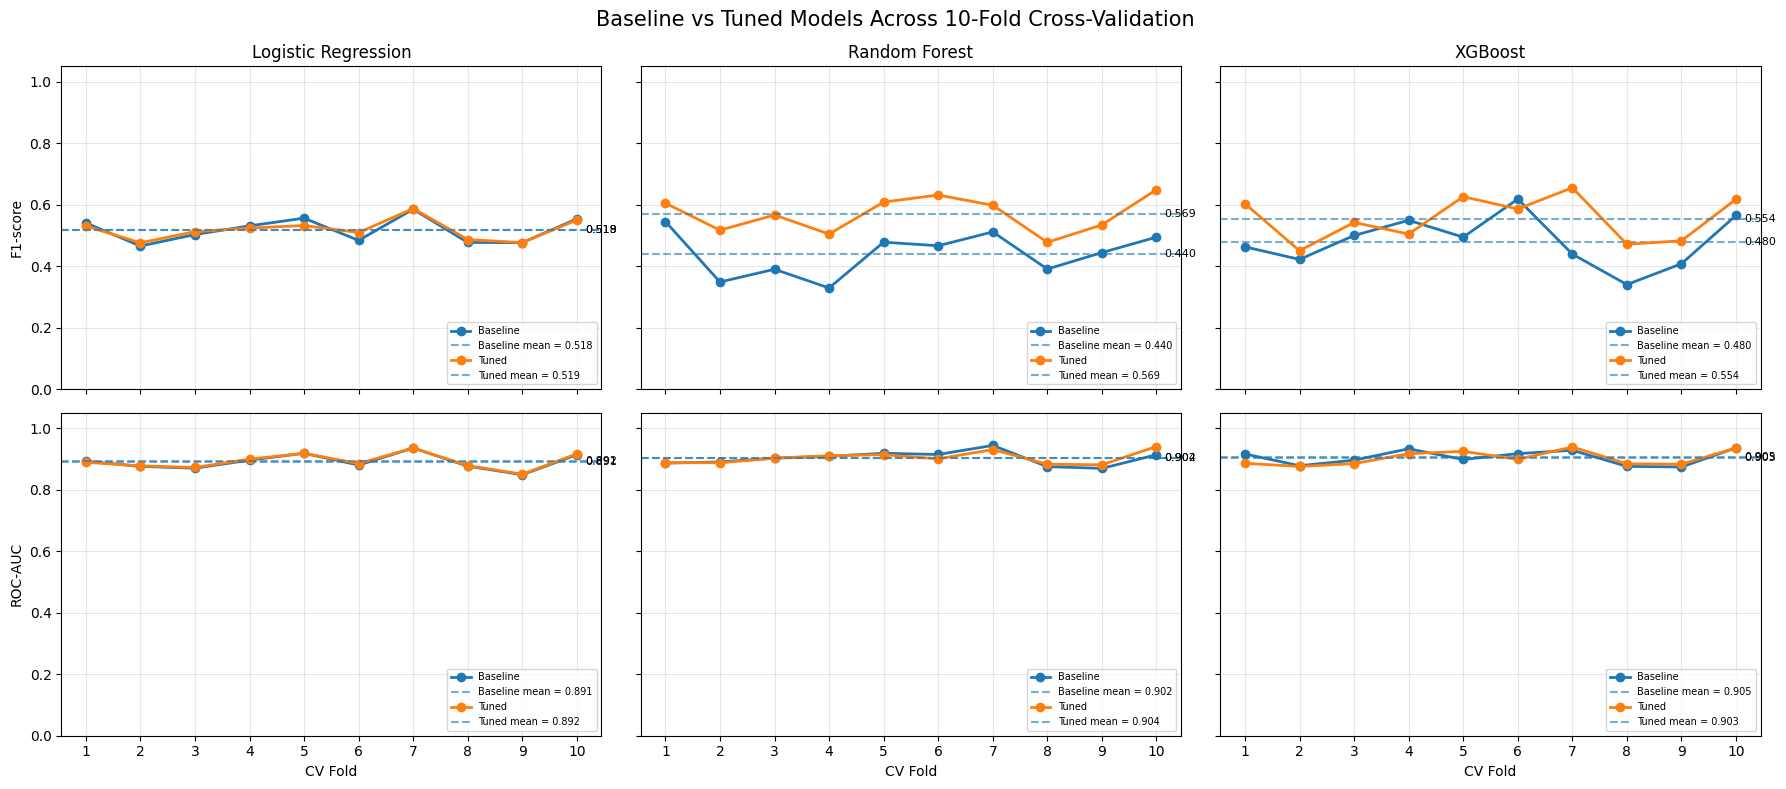

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load saved CV fold files
lr_cv = pd.read_csv("lr_cv_folds.csv")
rf_cv = pd.read_csv("rf_cv_folds.csv")
xgb_cv = pd.read_csv("xgb_cv_folds.csv")

# Combine all CV results
cv_df = pd.concat([lr_cv, rf_cv, xgb_cv], ignore_index=True)

# Clean labels
cv_df["Algorithm"] = cv_df["Algorithm"].astype(str).str.strip()
cv_df["Version"] = cv_df["Version"].astype(str).str.strip()

# Standardise model names
name_map = {
    "LR": "Logistic Regression",
    "Logistic Regression": "Logistic Regression",
    "RF": "Random Forest",
    "Random Forest": "Random Forest",
    "XGB": "XGBoost",
    "XGBoost": "XGBoost"
}

cv_df["Algorithm_clean"] = cv_df["Algorithm"].map(name_map).fillna(cv_df["Algorithm"])

# Order
model_order = ["Logistic Regression", "Random Forest", "XGBoost"]
report_metrics = ["F1-score", "ROC-AUC"]
versions = ["Baseline", "Tuned"]

# 2 rows x 3 columns
# Row 1 = F1-score
# Row 2 = ROC-AUC
# Columns = LR, RF, XGBoost
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey="row")

for col, model in enumerate(model_order):
    model_data = cv_df[cv_df["Algorithm_clean"] == model].copy()
    
    for row, metric in enumerate(report_metrics):
        ax = axes[row, col]
        
        for version in versions:
            version_data = (
                model_data[model_data["Version"].str.lower() == version.lower()]
                .sort_values("Fold")
            )
            
            if not version_data.empty:
                mean_value = version_data[metric].mean()
                
                # Fold-by-fold line
                ax.plot(
                    version_data["Fold"],
                    version_data[metric],
                    marker="o",
                    linewidth=2,
                    label=f"{version}"
                )
                
                # Mean line
                ax.axhline(
                    mean_value,
                    linestyle="--",
                    alpha=0.6,
                    label=f"{version} mean = {mean_value:.3f}"
                )
                
                # Mean value text
                ax.text(
                    10.15,
                    mean_value,
                    f"{mean_value:.3f}",
                    va="center",
                    fontsize=8
                )
        
        if row == 0:
            ax.set_title(model)
        
        if col == 0:
            ax.set_ylabel(metric)
        
        if row == 1:
            ax.set_xlabel("CV Fold")
        
        ax.set_xticks(range(1, 11))
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc="lower right")

fig.suptitle(
    "Baseline vs Tuned Models Across 10-Fold Cross-Validation",
    fontsize=15
)

plt.tight_layout()
plt.savefig("baseline_vs_tuned_f1_auc_cv_6plots.png", dpi=300, bbox_inches="tight")
plt.show()

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Algorithm,,,,,
Logistic Regression,0.8365,0.3926,0.7657,0.5187,0.8922
Random Forest,0.8905,0.5204,0.6295,0.5694,0.9037
XGBoost,0.8879,0.5094,0.6103,0.5541,0.9028


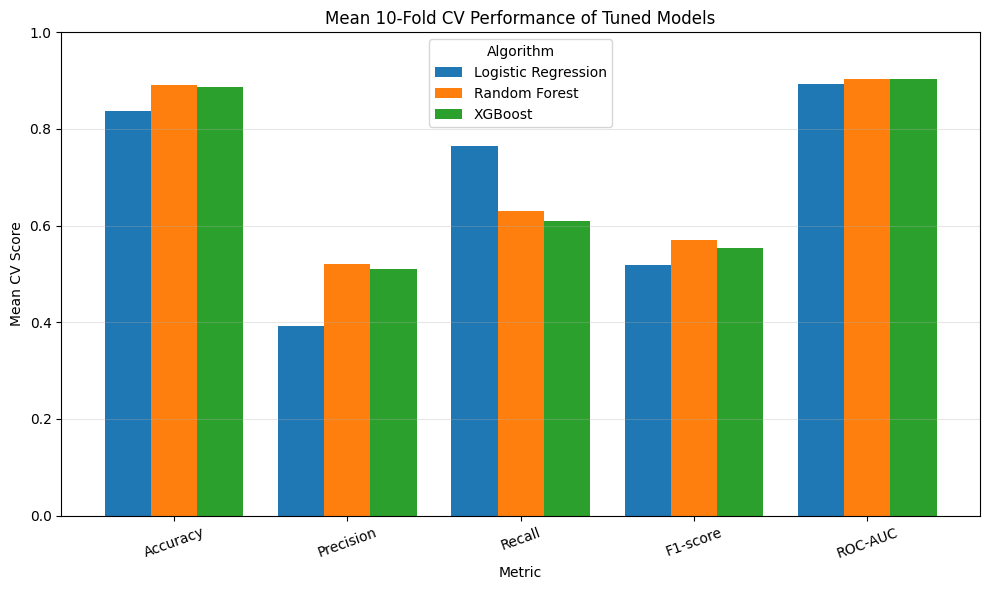

In [6]:
cv_df = pd.concat([lr_cv, rf_cv, xgb_cv], ignore_index=True)

# Clean labels
cv_df["Algorithm"] = cv_df["Algorithm"].astype(str).str.strip()
cv_df["Version"] = cv_df["Version"].astype(str).str.strip()

# Standardise algorithm names in case some files use LR/RF/XGB
name_map = {
    "LR": "Logistic Regression",
    "Logistic Regression": "Logistic Regression",
    "RF": "Random Forest",
    "Random Forest": "Random Forest",
    "XGB": "XGBoost",
    "XGBoost": "XGBoost"
}

cv_df["Algorithm"] = cv_df["Algorithm"].map(name_map).fillna(cv_df["Algorithm"])

# Keep only tuned models
tuned_df = cv_df[cv_df["Version"].str.lower() == "tuned"].copy()

# Metrics to compare
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

# Mean score across the 10 CV folds
mean_scores = (
    tuned_df
    .groupby("Algorithm")[metrics]
    .mean()
    .reindex(["Logistic Regression", "Random Forest", "XGBoost"])
)

display(mean_scores.round(4))

# Grouped bar chart
ax = mean_scores.T.plot(kind="bar", figsize=(10, 6), width=0.8)

plt.title("Mean 10-Fold CV Performance of Tuned Models")
plt.ylabel("Mean CV Score")
plt.xlabel("Metric")
plt.ylim(0, 1.0)
plt.xticks(rotation=20)
plt.legend(title="Algorithm")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()